# Bug Prioritization — Binary Classification

## Problem
Predict whether a bug is **High Priority** (P1, P2) or **Low Priority** (P3, P4, P5)

## Dataset
Eclipse Open Source Dataset — ~85,000 samples

## Target
`target` → Binary: `1` = High (P1/P2), `0` = Low (P3/P4/P5)

## Paths
| Path | Text Representation | Pipeline |
|---|---|---|
| **A** | TF-IDF (sparse, 5k features) | SMOTE → LR / RF / XGBoost / LinearSVC |
| **B** | `all-MiniLM-L6-v2` base embeddings | LR / RF / XGBoost + tuned XGB + threshold search |
| **C** | Fine-tuned embedding model | Same as Path B |

## Imports

In [1]:
import mlflow
import mlflow.sklearn
import mlflow.xgboost

import pandas as pd
import numpy as np
import re
import os
import joblib
import json

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import LinearSVC
from sklearn.calibration import CalibratedClassifierCV
from sklearn.dummy import DummyClassifier
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    f1_score,
    precision_recall_curve,
)
from scipy.sparse import hstack, csr_matrix
import scipy.sparse as sp

from imblearn.over_sampling import SMOTE
from xgboost import XGBClassifier
from sentence_transformers import SentenceTransformer

pd.set_option("display.max_columns", None)
pd.set_option("display.max_colwidth", 100)
sns.set_theme(style="whitegrid")
%matplotlib inline

d:\Projects\Machine Learning\bug-priority-classifier\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [9]:
# ─────────────────────────────────────────────────────────────────────────
# MLflow Setup
# Run `mlflow ui` in the project root to open the tracking UI at http://127.0.0.1:5000
# ─────────────────────────────────────────────────────────────────────────
from sklearn.metrics import precision_score, recall_score, f1_score as _f1

EXPERIMENT_NAME = "bug-priority-classifier"
mlflow.set_tracking_uri(
    "sqlite:///D:/Projects/Machine Learning/bug-priority-classifier/mlflow.db"
)
mlflow.set_experiment(EXPERIMENT_NAME)


def log_run_metrics(y_true, y_pred, y_prob, threshold=0.5):
    """Log standard binary classification metrics to the active MLflow run.
    Call this INSIDE a `with mlflow.start_run():` block.
    """
    mlflow.log_metrics(
        {
            "precision_hi": round(
                precision_score(y_true, y_pred, pos_label=1, zero_division=0), 4
            ),
            "recall_hi": round(
                recall_score(y_true, y_pred, pos_label=1, zero_division=0), 4
            ),
            "f1_hi": round(_f1(y_true, y_pred, pos_label=1, zero_division=0), 4),
            "auc_roc": round(roc_auc_score(y_true, y_prob), 4),
            "accuracy": round((y_true == y_pred).mean(), 4),
            "threshold": threshold,
        }
    )


print(f"✓ MLflow experiment '{EXPERIMENT_NAME}' is ready.")
print("  → Launch UI: mlflow ui  (from project root)")
print("  → Then open: http://127.0.0.1:5000")


2026/03/15 22:25:49 INFO mlflow.tracking.fluent: Experiment with name 'bug-priority-classifier' does not exist. Creating a new experiment.


✓ MLflow experiment 'bug-priority-classifier' is ready.
  → Launch UI: mlflow ui  (from project root)
  → Then open: http://127.0.0.1:5000


In [11]:
print(mlflow.get_tracking_uri())
# Should print: sqlite:///D:/Projects/.../notebooks/mlflow.db

sqlite:///D:/Projects/Machine Learning/bug-priority-classifier/mlflow.db


## Environment Check

In [12]:
import torch
import sys

print("CUDA Available:", torch.cuda.is_available())
print("Python:", sys.executable)

CUDA Available: True
Python: d:\Projects\Machine Learning\bug-priority-classifier\.venv\Scripts\python.exe


## Read Data

In [13]:
df = pd.read_csv("../data/raw/eclipse_dataset.csv")

print("DATASET SHAPE:", df.shape)
print("\nCOLUMNS:", df.columns.tolist())
print("\nPRIORITY DISTRIBUTION:")
print(df["Priority"].value_counts())
print("\nNORMALIZED:")
print(df["Priority"].value_counts(normalize=True).round(3))
print("\nMISSING VALUES:")
print(df.isnull().sum())
print("\nDUPLICATES:", df.duplicated().sum())
print("\nSAMPLE:")
df.head()

DATASET SHAPE: (85156, 11)

COLUMNS: ['Issue_id', 'Priority', 'Component', 'Duplicated_issue', 'Title', 'Description', 'Status', 'Resolution', 'Version', 'Created_time', 'Resolved_time']

PRIORITY DISTRIBUTION:
Priority
P3    74830
P2     5108
P1     2077
P4     1942
P5     1199
Name: count, dtype: int64

NORMALIZED:
Priority
P3    0.879
P2    0.060
P1    0.024
P4    0.023
P5    0.014
Name: proportion, dtype: float64

MISSING VALUES:
Issue_id                0
Priority                0
Component               0
Duplicated_issue    70752
Title                   0
Description           129
Status                  0
Resolution              0
Version                 0
Created_time            0
Resolved_time           0
dtype: int64

DUPLICATES: 0

SAMPLE:


,Issue_id,Priority,Component,Duplicated_issue,Title,Description,Status,Resolution,Version,Created_time,Resolved_time
0,1,P3,Team,NaN,Usability issue with external editors (1GE6IRL),- Setup a project that contains a *.gif resource; \t- release project to CVS; \t- edit the *.gif...,CLOSED,FIXED,2.0,2001-10-10 21:34:00 -0400,2012-02-09 15:57:47 -0500
1,2,P5,Team,NaN,Opening repository resources doesnt honor type (1GE6I1Q),Opening repository resource always open the default text editor and doesnt; \thonor any mapping ...,RESOLVED,FIXED,2.0,2001-10-10 21:34:00 -0400,2002-05-07 10:33:56 -0400
2,3,P5,Team,NaN,Sync does not indicate deletion (1GIEN83),KM (10/2/2001 5:55:18 PM); \tThis PR about the deletion indicator in the sync viewer being too s...,RESOLVED,FIXED,2.0,2001-10-10 21:34:00 -0400,2010-05-07 10:28:53 -0400
3,4,P5,Team,NaN,need better error message if catching up over read-only resource (1GF69TF),- become synchronized with some project in a repository; - use a different Eclipse to make a cha...,RESOLVED,FIXED,2.0,2001-10-10 21:34:00 -0400,2002-03-01 16:27:31 -0500
4,5,P3,Team,NaN,ISharingManager sharing API inconsistent (1GAUL8H),For getting/setting the managed state of a resource; the methods are:; ; isManaged(resource) and...,RESOLVED,WONTFIX,2.0,2001-10-10 21:34:00 -0400,2008-08-15 08:04:36 -0400


## Clean Data

### Normalize Column Names

In [14]:
def to_snake_case(col):
    return col.strip().lower().replace(" ", "_")


df.columns = [to_snake_case(col) for col in df.columns]
print("Columns after normalization:", df.columns.tolist())

Columns after normalization: ['issue_id', 'priority', 'component', 'duplicated_issue', 'title', 'description', 'status', 'resolution', 'version', 'created_time', 'resolved_time']


### Map Target

In [15]:
df["target"] = df["priority"].apply(lambda x: 1 if x in ["P1", "P2"] else 0)

print("High (1):", (df["target"] == 1).sum())
print("Low  (0):", (df["target"] == 0).sum())
print(
    "Imbalance ratio:",
    round((df["target"] == 0).sum() / (df["target"] == 1).sum(), 2),
    ":1",
)

High (1): 7185
Low  (0): 77971
Imbalance ratio: 10.85 :1


### Text Cleaning

In [16]:
def clean_text(text: str) -> str:
    text = str(text)
    # Remove bug IDs like (1GE6IRL)
    text = re.sub(r"\([A-Za-z0-9]+\)", "", text)
    # Remove timestamps like (05/27/01 5:10:19 PM)
    text = re.sub(r"\(\d{1,2}/\d{1,2}/\d{1,2}.*?\)", "", text)
    # Remove name prefixes like "KM:" "EG:"
    text = re.sub(r"\b[A-Z]{2,3}\s*:", "", text)
    # Lowercase
    text = text.lower()
    # Remove tab characters
    text = re.sub(r"\\t", " ", text)
    # Remove special characters
    text = re.sub(r"[^a-z0-9\s]", " ", text)
    # Collapse whitespace
    text = re.sub(r"\s+", " ", text).strip()
    return text


# Combine title + description, then clean
df["text"] = df["title"].fillna("") + " " + df["description"].fillna("")
df["text"] = df["text"].apply(clean_text)

print("Sample cleaned text:")
print(df["text"][0][:300])

Sample cleaned text:
usability issue with external editors setup a project that contains a gif resource release project to cvs edit the gif resource with an external editor e g paintshop save and close external editor in navigator open the icon resource and verify that your changes are there release project nothing to r


### Drop Identifier / Leakage Columns

In [17]:
# Keep: component, version, created_time for feature engineering
# Drop: identifiers, raw text fields, target-leaking columns
COLS_TO_DROP = [
    "issue_id",
    "priority",
    "duplicated_issue",
    "title",
    "description",
    "status",
    "resolution",
    "resolved_time",
]

df_clean = df.drop(columns=COLS_TO_DROP).copy()
df_clean["created_time"] = pd.to_datetime(df_clean["created_time"], utc=True)

print("Shape after drop:", df_clean.shape)
print("Columns:", df_clean.columns.tolist())
print("\nMissing values:")
print(df_clean.isnull().sum())

Shape after drop: (85156, 5)
Columns: ['component', 'version', 'created_time', 'target', 'text']

Missing values:
component       0
version         0
created_time    0
target          0
text            0
dtype: int64


## Feature Engineering

### Time Features

In [18]:
df_clean["created_hour"] = df_clean["created_time"].dt.hour
df_clean["created_dayofweek"] = df_clean["created_time"].dt.dayofweek
df_clean["created_month"] = df_clean["created_time"].dt.month
df_clean["created_year"] = df_clean["created_time"].dt.year

df_clean = df_clean.drop(columns=["created_time"])
print("Time features added. Shape:", df_clean.shape)

Time features added. Shape: (85156, 8)


### Text Statistical Features

In [19]:
df_clean["text_length"] = df_clean["text"].apply(len)
df_clean["word_count"] = df_clean["text"].apply(lambda x: len(x.split()))
df_clean["avg_word_length"] = df_clean["text"].apply(
    lambda x: np.mean([len(w) for w in x.split()]) if x.split() else 0
)

print("Text features added.")
print(df_clean[["text_length", "word_count", "avg_word_length"]].describe())

# Save processed dataset
os.makedirs("../data/processed", exist_ok=True)
df_clean.to_csv("../data/processed/cleaned_dataset_with_features.csv", index=False)
print("Saved: ../data/processed/cleaned_dataset_with_features.csv")

Text features added.
        text_length    word_count  avg_word_length
count  85156.000000  85156.000000     85156.000000
mean    1107.921849    175.201289         4.958498
std     2483.002058    376.837314         0.787545
min        0.000000      0.000000         0.000000
25%      273.000000     47.000000         4.433587
50%      456.000000     80.000000         4.780488
75%      857.000000    149.000000         5.309859
max    29346.000000   9847.000000        21.024390
Saved: ../data/processed/cleaned_dataset_with_features.csv


## Feature Split

In [20]:
X_text = df_clean["text"]

X_meta = df_clean[["component", "version"]]

X_additional = df_clean[
    [
        "created_hour",
        "created_dayofweek",
        "created_month",
        "created_year",
        "text_length",
        "word_count",
        "avg_word_length",
    ]
]

y = df_clean["target"]

print("X_text:      ", X_text.shape)
print("X_meta:      ", X_meta.shape)
print("X_additional:", X_additional.shape)
print("y:           ", y.shape)

X_text:       (85156,)
X_meta:       (85156, 2)
X_additional: (85156, 7)
y:            (85156,)


## Train-Test Split

In [21]:
(
    X_text_train,
    X_text_test,
    X_meta_train,
    X_meta_test,
    X_add_train,
    X_add_test,
    y_train,
    y_test,
) = train_test_split(
    X_text, X_meta, X_additional, y, test_size=0.2, random_state=42, stratify=y
)

print("Train size:", X_text_train.shape[0])
print("Test size: ", X_text_test.shape[0])
print("\nTrain class distribution:")
print(y_train.value_counts())

# Compute class imbalance ratio once — used by XGBoost in all paths
scale = len(y_train[y_train == 0]) / len(y_train[y_train == 1])
print(f"\nscale_pos_weight (for XGBoost): {scale:.2f}")

Train size: 68124
Test size:  17032

Train class distribution:
target
0    62376
1     5748
Name: count, dtype: int64

scale_pos_weight (for XGBoost): 10.85


## Encoding

### OneHotEncoder — Component & Version

In [22]:
ohe = OneHotEncoder(sparse_output=True, handle_unknown="ignore")
X_meta_train_encoded = ohe.fit_transform(X_meta_train)
X_meta_test_encoded = ohe.transform(X_meta_test)

print("OHE train:", X_meta_train_encoded.shape)
print("OHE test: ", X_meta_test_encoded.shape)

OHE train: (68124, 64)
OHE test:  (17032, 64)


### StandardScaler — Additional Features

In [23]:
scaler = StandardScaler()
X_add_train_scaled = csr_matrix(scaler.fit_transform(X_add_train))
X_add_test_scaled = csr_matrix(scaler.transform(X_add_test))

print("Scaled additional train:", X_add_train_scaled.shape)
print("Scaled additional test: ", X_add_test_scaled.shape)

Scaled additional train: (68124, 7)
Scaled additional test:  (17032, 7)


---
# PATH A — TF-IDF Models

### TF-IDF Vectorization

In [24]:
tfidf = TfidfVectorizer(
    max_features=5000, ngram_range=(1, 2), stop_words="english", min_df=5
)

X_text_train_tfidf = tfidf.fit_transform(X_text_train)
X_text_test_tfidf = tfidf.transform(X_text_test)

print("TF-IDF train:", X_text_train_tfidf.shape)
print("TF-IDF test: ", X_text_test_tfidf.shape)

TF-IDF train: (68124, 5000)
TF-IDF test:  (17032, 5000)


### Combine Features

In [25]:
X_train_a = hstack([X_text_train_tfidf, X_meta_train_encoded, X_add_train_scaled])
X_test_a = hstack([X_text_test_tfidf, X_meta_test_encoded, X_add_test_scaled])

print("X_train_a:", X_train_a.shape)
print("X_test_a: ", X_test_a.shape)

X_train_a: (68124, 5071)
X_test_a:  (17032, 5071)


### SMOTE Oversampling

In [26]:
smote = SMOTE(random_state=42)
X_train_a_resampled, y_train_resampled = smote.fit_resample(X_train_a, y_train)

print("Resampled shape:", X_train_a_resampled.shape)
print("\nOriginal distribution:")
print(y_train.value_counts())
print("\nResampled distribution:")
print(y_train_resampled.value_counts())

Resampled shape: (124752, 5071)

Original distribution:
target
0    62376
1     5748
Name: count, dtype: int64

Resampled distribution:
target
0    62376
1    62376
Name: count, dtype: int64


### Baseline — Dummy Classifier

In [27]:
with mlflow.start_run(run_name="Dummy_PathA"):
    mlflow.set_tags({"path": "A", "representation": "tfidf", "model_type": "Dummy"})
    mlflow.log_params({"strategy": "most_frequent"})

    dummy_clf = DummyClassifier(strategy="most_frequent", random_state=42)
    dummy_clf.fit(X_train_a_resampled, y_train_resampled)
    y_pred_dummy = dummy_clf.predict(X_test_a)
    y_prob_dummy = dummy_clf.predict_proba(X_test_a)[:, 1]

    log_run_metrics(y_test, y_pred_dummy, y_prob_dummy)
    mlflow.sklearn.log_model(dummy_clf, "model")

    print("Dummy Classifier:")
    print(classification_report(y_test, y_pred_dummy, target_names=["Low", "High"]))
    print("AUC-ROC:", round(roc_auc_score(y_test, y_prob_dummy), 4))


2026/03/15 22:27:07 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/03/15 22:27:07 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


Dummy Classifier:
              precision    recall  f1-score   support

         Low       0.92      1.00      0.96     15595
        High       0.00      0.00      0.00      1437

    accuracy                           0.92     17032
   macro avg       0.46      0.50      0.48     17032
weighted avg       0.84      0.92      0.88     17032

AUC-ROC: 0.5


d:\Projects\Machine Learning\bug-priority-classifier\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
d:\Projects\Machine Learning\bug-priority-classifier\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
d:\Projects\Machine Learning\bug-priority-classifier\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _

### Logistic Regression (SMOTE)

In [28]:
with mlflow.start_run(run_name="LR_SMOTE_PathA"):
    mlflow.set_tags(
        {
            "path": "A",
            "representation": "tfidf",
            "model_type": "LogisticRegression",
            "sampling": "SMOTE",
        }
    )
    mlflow.log_params({"C": 1.0, "max_iter": 1000, "class_weight": "none"})

    logreg_smote = LogisticRegression(max_iter=1000, random_state=42)
    logreg_smote.fit(X_train_a_resampled, y_train_resampled)
    y_pred_lr_smote = logreg_smote.predict(X_test_a)
    y_prob_lr_smote = logreg_smote.predict_proba(X_test_a)[:, 1]

    log_run_metrics(y_test, y_pred_lr_smote, y_prob_lr_smote)
    mlflow.sklearn.log_model(logreg_smote, "model")

    print("LR (SMOTE):")
    print(classification_report(y_test, y_pred_lr_smote, target_names=["Low", "High"]))
    print("AUC-ROC:", round(roc_auc_score(y_test, y_prob_lr_smote), 4))


2026/03/15 22:27:20 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/03/15 22:27:20 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


LR (SMOTE):
              precision    recall  f1-score   support

         Low       0.96      0.75      0.84     15595
        High       0.19      0.64      0.29      1437

    accuracy                           0.74     17032
   macro avg       0.57      0.69      0.57     17032
weighted avg       0.89      0.74      0.79     17032

AUC-ROC: 0.7665


### Logistic Regression (class_weight=balanced)

In [29]:
with mlflow.start_run(run_name="LR_Balanced_PathA"):
    mlflow.set_tags(
        {
            "path": "A",
            "representation": "tfidf",
            "model_type": "LogisticRegression",
            "sampling": "class_weight",
        }
    )
    mlflow.log_params({"C": 1, "class_weight": "balanced", "max_iter": 1000})

    logreg_bal = LogisticRegression(
        C=1, class_weight="balanced", max_iter=1000, random_state=42, n_jobs=-1
    )
    logreg_bal.fit(X_train_a, y_train)
    y_pred_lr_bal = logreg_bal.predict(X_test_a)
    y_prob_lr_bal = logreg_bal.predict_proba(X_test_a)[:, 1]

    log_run_metrics(y_test, y_pred_lr_bal, y_prob_lr_bal)
    mlflow.sklearn.log_model(logreg_bal, "model")

    print("LR (balanced):")
    print(classification_report(y_test, y_pred_lr_bal, target_names=["Low", "High"]))
    print("AUC-ROC:", round(roc_auc_score(y_test, y_prob_lr_bal), 4))


d:\Projects\Machine Learning\bug-priority-classifier\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1184: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)
2026/03/15 22:27:25 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/03/15 22:27:25 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


LR (balanced):
              precision    recall  f1-score   support

         Low       0.96      0.73      0.83     15595
        High       0.19      0.68      0.30      1437

    accuracy                           0.73     17032
   macro avg       0.57      0.70      0.56     17032
weighted avg       0.90      0.73      0.79     17032

AUC-ROC: 0.774


### Random Forest

In [30]:
with mlflow.start_run(run_name="RandomForest_PathA"):
    mlflow.set_tags(
        {"path": "A", "representation": "tfidf", "model_type": "RandomForest"}
    )
    mlflow.log_params({"n_estimators": 100, "class_weight": "balanced"})

    rf_clf = RandomForestClassifier(
        n_estimators=100, random_state=42, n_jobs=-1, class_weight="balanced"
    )
    rf_clf.fit(X_train_a, y_train)
    y_pred_rf_a = rf_clf.predict(X_test_a)
    y_prob_rf_a = rf_clf.predict_proba(X_test_a)[:, 1]

    log_run_metrics(y_test, y_pred_rf_a, y_prob_rf_a)
    mlflow.sklearn.log_model(rf_clf, "model")

    print("Random Forest:")
    print(classification_report(y_test, y_pred_rf_a, target_names=["Low", "High"]))
    print("AUC-ROC:", round(roc_auc_score(y_test, y_prob_rf_a), 4))


2026/03/15 22:27:52 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/03/15 22:27:52 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


Random Forest:
              precision    recall  f1-score   support

         Low       0.92      1.00      0.96     15595
        High       0.48      0.04      0.07      1437

    accuracy                           0.92     17032
   macro avg       0.70      0.52      0.51     17032
weighted avg       0.88      0.92      0.88     17032

AUC-ROC: 0.7891


### XGBoost

In [31]:
with mlflow.start_run(run_name="XGBoost_PathA"):
    mlflow.set_tags({"path": "A", "representation": "tfidf", "model_type": "XGBoost"})
    mlflow.log_params(
        {
            "n_estimators": 200,
            "max_depth": 6,
            "learning_rate": 0.1,
            "scale_pos_weight": scale,
            "eval_metric": "auc",
            "device": "cuda",
        }
    )

    xgb_a = XGBClassifier(
        n_estimators=200,
        max_depth=6,
        learning_rate=0.1,
        scale_pos_weight=scale,
        tree_method="hist",
        eval_metric="auc",
        device="cuda",
        random_state=42,
        n_jobs=-1,
    )
    xgb_a.fit(X_train_a, y_train, eval_set=[(X_test_a, y_test)], verbose=50)
    y_pred_xgb_a = xgb_a.predict(X_test_a)
    y_prob_xgb_a = xgb_a.predict_proba(X_test_a)[:, 1]

    mlflow.log_metric(
        "best_iteration", getattr(xgb_a, "best_iteration", None) or xgb_a.n_estimators
    )
    log_run_metrics(y_test, y_pred_xgb_a, y_prob_xgb_a)
    mlflow.xgboost.log_model(xgb_a, "model")

    print("\nXGBoost (Path A):")
    print(classification_report(y_test, y_pred_xgb_a, target_names=["Low", "High"]))
    print("AUC-ROC:", round(roc_auc_score(y_test, y_prob_xgb_a), 4))


[0]	validation_0-auc:0.75133
[50]	validation_0-auc:0.68025
[100]	validation_0-auc:0.67753
[150]	validation_0-auc:0.67839
[199]	validation_0-auc:0.67891


d:\Projects\Machine Learning\bug-priority-classifier\.venv\Lib\site-packages\xgboost\core.py:751: UserWarning: [22:28:07] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\common\error_msg.cc:62: Falling back to prediction using DMatrix due to mismatched devices. This might lead to higher memory usage and slower performance. XGBoost is running on: cuda:0, while the input data is on: cpu.
Potential solutions:
- Use a data structure that matches the device ordinal in the booster.
- Set the device for booster before call to inplace_predict.

This warning will only be shown once.

  return func(**kwargs)
2026/03/15 22:28:07 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.



XGBoost (Path A):
              precision    recall  f1-score   support

         Low       0.96      0.59      0.73     15595
        High       0.14      0.73      0.24      1437

    accuracy                           0.60     17032
   macro avg       0.55      0.66      0.48     17032
weighted avg       0.89      0.60      0.69     17032

AUC-ROC: 0.6789


### LinearSVC (Calibrated)

In [32]:
with mlflow.start_run(run_name="LinearSVC_PathA"):
    mlflow.set_tags({"path": "A", "representation": "tfidf", "model_type": "LinearSVC"})
    mlflow.log_params(
        {"class_weight": "balanced", "max_iter": 2000, "calibration_cv": 5}
    )

    svc = LinearSVC(class_weight="balanced", max_iter=2000, random_state=42)
    svc_cal = CalibratedClassifierCV(svc, cv=5)
    svc_cal.fit(X_train_a, y_train)
    y_pred_svc = svc_cal.predict(X_test_a)
    y_prob_svc = svc_cal.predict_proba(X_test_a)[:, 1]

    log_run_metrics(y_test, y_pred_svc, y_prob_svc)
    mlflow.sklearn.log_model(svc_cal, "model")

    print("LinearSVC (calibrated):")
    print(classification_report(y_test, y_pred_svc, target_names=["Low", "High"]))
    print("AUC-ROC:", round(roc_auc_score(y_test, y_prob_svc), 4))


2026/03/15 22:28:59 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/03/15 22:28:59 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


LinearSVC (calibrated):
              precision    recall  f1-score   support

         Low       0.92      1.00      0.96     15595
        High       0.09      0.00      0.00      1437

    accuracy                           0.92     17032
   macro avg       0.50      0.50      0.48     17032
weighted avg       0.85      0.92      0.88     17032

AUC-ROC: 0.7579


### PATH A — Dynamic Results

In [33]:
from sklearn.metrics import precision_score, recall_score


def get_metrics(y_true, y_pred, y_prob, name, threshold=0.50):
    return {
        "Model": name,
        "Threshold": threshold,
        "Precision (Hi)": round(
            precision_score(y_true, y_pred, pos_label=1, zero_division=0), 3
        ),
        "Recall (Hi)": round(
            recall_score(y_true, y_pred, pos_label=1, zero_division=0), 3
        ),
        "F1 (Hi)": round(f1_score(y_true, y_pred, pos_label=1, zero_division=0), 3),
        "AUC-ROC": round(roc_auc_score(y_true, y_prob), 4),
        "Accuracy": round((y_true == y_pred).mean(), 4),
    }


results_a = []

# Dummy
results_a.append(get_metrics(y_test, y_pred_dummy, y_prob_dummy, "Dummy Classifier"))
# LR SMOTE
results_a.append(get_metrics(y_test, y_pred_lr_smote, y_prob_lr_smote, "LR (SMOTE)"))
# LR balanced
results_a.append(get_metrics(y_test, y_pred_lr_bal, y_prob_lr_bal, "LR (balanced)"))
# RF
results_a.append(get_metrics(y_test, y_pred_rf_a, y_prob_rf_a, "Random Forest"))
# XGBoost
results_a.append(get_metrics(y_test, y_pred_xgb_a, y_prob_xgb_a, "XGBoost"))
# LinearSVC
results_a.append(get_metrics(y_test, y_pred_svc, y_prob_svc, "LinearSVC (calibrated)"))

df_results_a = pd.DataFrame(results_a).sort_values("F1 (Hi)", ascending=False)

# Highlight the winner row
best_a_idx = df_results_a["F1 (Hi)"].idxmax()

print("=" * 65)
print("PATH A — Results Summary")
print("=" * 65)
print(df_results_a.to_string(index=False))
print(f"\n✓  Best model (by F1): {df_results_a.loc[best_a_idx, 'Model']}")


PATH A — Results Summary
                 Model  Threshold  Precision (Hi)  Recall (Hi)  F1 (Hi)  AUC-ROC  Accuracy
         LR (balanced)        0.5           0.189        0.677    0.295   0.7740    0.7275
            LR (SMOTE)        0.5           0.190        0.637    0.293   0.7665    0.7404
               XGBoost        0.5           0.141        0.733    0.236   0.6789    0.5991
         Random Forest        0.5           0.477        0.035    0.066   0.7891    0.9153
LinearSVC (calibrated)        0.5           0.091        0.001    0.001   0.7579    0.9151
      Dummy Classifier        0.5           0.000        0.000    0.000   0.5000    0.9156

✓  Best model (by F1): LR (balanced)


---
# PATH B — Base Embeddings (`all-MiniLM-L6-v2`)

### Load / Compute Embeddings

In [34]:
emb_model = SentenceTransformer("all-MiniLM-L6-v2")

if os.path.exists("../data/processed/text_embeddings.npy"):
    print("Loading cached embeddings...")
    text_embeddings_b = np.load("../data/processed/text_embeddings.npy")
else:
    print("Computing embeddings...")
    text_embeddings_b = emb_model.encode(
        X_text.tolist(), batch_size=256, show_progress_bar=True, device="cuda"
    )
    np.save("../data/processed/text_embeddings.npy", text_embeddings_b)

print("Embeddings shape:", text_embeddings_b.shape)

Loading weights: 100%|██████████| 103/103 [00:00<00:00, 6943.21it/s]
BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading cached embeddings...
Embeddings shape: (85156, 384)


### Align Train/Test Splits

In [35]:
X_text_train_emb_b = text_embeddings_b[X_text_train.index]
X_text_test_emb_b = text_embeddings_b[X_text_test.index]

X_text_train_emb_b_csr = csr_matrix(X_text_train_emb_b)
X_text_test_emb_b_csr = csr_matrix(X_text_test_emb_b)

print("Train embeddings:", X_text_train_emb_b_csr.shape)
print("Test  embeddings:", X_text_test_emb_b_csr.shape)

Train embeddings: (68124, 384)
Test  embeddings: (17032, 384)


### Combine Features

In [36]:
X_train_b = hstack([X_text_train_emb_b_csr, X_meta_train_encoded, X_add_train_scaled])
X_test_b = hstack([X_text_test_emb_b_csr, X_meta_test_encoded, X_add_test_scaled])

print("X_train_b:", X_train_b.shape)
print("X_test_b: ", X_test_b.shape)

X_train_b: (68124, 455)
X_test_b:  (17032, 455)


### Multi-Model Comparison

In [37]:
models_b = {
    "Logistic Regression": LogisticRegression(
        C=1, class_weight="balanced", max_iter=1000, random_state=42, n_jobs=-1
    ),
    "Random Forest": RandomForestClassifier(
        n_estimators=100, random_state=42, n_jobs=-1, class_weight="balanced"
    ),
    "XGBoost": XGBClassifier(
        n_estimators=200,
        max_depth=6,
        learning_rate=0.1,
        scale_pos_weight=scale,
        tree_method="hist",
        eval_metric="auc",
        device="cuda",
        random_state=42,
        n_jobs=-1,
    ),
}

_b_params = {
    "Logistic Regression": {"C": 1, "class_weight": "balanced", "max_iter": 1000},
    "Random Forest": {"n_estimators": 100, "class_weight": "balanced"},
    "XGBoost": {"n_estimators": 200, "max_depth": 6, "learning_rate": 0.1},
}

for name, model in models_b.items():
    run_name = name.replace(" ", "_") + "_PathB"
    with mlflow.start_run(run_name=run_name):
        mlflow.set_tags({"path": "B", "representation": "base-emb", "model_type": name})
        mlflow.log_params(_b_params[name])

        print(f"\n{'=' * 50}")
        print(f"Training: {name}")
        if name == "XGBoost":
            model.fit(X_train_b, y_train, eval_set=[(X_test_b, y_test)], verbose=50)
        else:
            model.fit(X_train_b, y_train)
        y_pred = model.predict(X_test_b)
        y_proba = model.predict_proba(X_test_b)[:, 1]

        log_run_metrics(y_test, y_pred, y_proba)
        mlflow.sklearn.log_model(model, "model")

        print(classification_report(y_test, y_pred, target_names=["Low", "High"]))
        print("AUC-ROC:", round(roc_auc_score(y_test, y_proba), 4))



Training: Logistic Regression


d:\Projects\Machine Learning\bug-priority-classifier\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1184: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)
2026/03/15 22:29:17 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/03/15 22:29:17 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


              precision    recall  f1-score   support

         Low       0.97      0.69      0.80     15595
        High       0.18      0.73      0.29      1437

    accuracy                           0.69     17032
   macro avg       0.57      0.71      0.55     17032
weighted avg       0.90      0.69      0.76     17032

AUC-ROC: 0.7812

Training: Random Forest


2026/03/15 22:31:11 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/03/15 22:31:11 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


              precision    recall  f1-score   support

         Low       0.92      1.00      0.96     15595
        High       0.71      0.01      0.01      1437

    accuracy                           0.92     17032
   macro avg       0.82      0.50      0.48     17032
weighted avg       0.90      0.92      0.88     17032

AUC-ROC: 0.763

Training: XGBoost
[0]	validation_0-auc:0.77733
[50]	validation_0-auc:0.80611
[100]	validation_0-auc:0.80886
[150]	validation_0-auc:0.80662
[199]	validation_0-auc:0.80452


2026/03/15 22:31:26 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/03/15 22:31:27 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


              precision    recall  f1-score   support

         Low       0.95      0.86      0.90     15595
        High       0.25      0.52      0.34      1437

    accuracy                           0.83     17032
   macro avg       0.60      0.69      0.62     17032
weighted avg       0.89      0.83      0.85     17032

AUC-ROC: 0.8045


### XGBoost Tuned (Early Stopping)

In [38]:
with mlflow.start_run(run_name="XGBoost_Tuned_PathB"):
    mlflow.set_tags(
        {
            "path": "B",
            "representation": "base-emb",
            "model_type": "XGBoost",
            "variant": "early_stop",
        }
    )
    mlflow.log_params(
        {
            "n_estimators": 500,
            "max_depth": 6,
            "learning_rate": 0.05,
            "scale_pos_weight": scale,
            "eval_metric": "auc",
            "early_stopping_rounds": 20,
        }
    )

    xgb_b_tuned = XGBClassifier(
        n_estimators=500,
        max_depth=6,
        learning_rate=0.05,
        scale_pos_weight=scale,
        tree_method="hist",
        eval_metric="auc",
        early_stopping_rounds=20,
        device="cuda",
        random_state=42,
        n_jobs=-1,
    )
    xgb_b_tuned.fit(X_train_b, y_train, eval_set=[(X_test_b, y_test)], verbose=50)

    y_pred_b_tuned = xgb_b_tuned.predict(X_test_b)
    y_prob_b_tuned = xgb_b_tuned.predict_proba(X_test_b)[:, 1]

    mlflow.log_metric("best_iteration", xgb_b_tuned.best_iteration)
    log_run_metrics(y_test, y_pred_b_tuned, y_prob_b_tuned)
    mlflow.xgboost.log_model(xgb_b_tuned, "model")

    print("\nTuned XGBoost (Path B):")
    print(classification_report(y_test, y_pred_b_tuned, target_names=["Low", "High"]))
    print("AUC-ROC:", round(roc_auc_score(y_test, y_prob_b_tuned), 4))
    print("Best iteration:", xgb_b_tuned.best_iteration)


[0]	validation_0-auc:0.77733
[50]	validation_0-auc:0.80619
[100]	validation_0-auc:0.81042
[150]	validation_0-auc:0.81185
[200]	validation_0-auc:0.81234
[229]	validation_0-auc:0.81197


2026/03/15 22:31:41 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.



Tuned XGBoost (Path B):
              precision    recall  f1-score   support

         Low       0.96      0.81      0.88     15595
        High       0.23      0.64      0.34      1437

    accuracy                           0.79     17032
   macro avg       0.60      0.72      0.61     17032
weighted avg       0.90      0.79      0.83     17032

AUC-ROC: 0.8125
Best iteration: 209


In [39]:
# New Cell 1 — same model, fixed eval metric (aucpr)
with mlflow.start_run(run_name="XGBoost_v2_aucpr_PathB"):
    mlflow.set_tags(
        {
            "path": "B",
            "representation": "base-emb",
            "model_type": "XGBoost",
            "variant": "aucpr",
        }
    )
    mlflow.log_params(
        {
            "n_estimators": 500,
            "max_depth": 6,
            "learning_rate": 0.05,
            "scale_pos_weight": scale,
            "eval_metric": "aucpr",
            "early_stopping_rounds": 20,
        }
    )

    xgb_b_v2 = XGBClassifier(
        n_estimators=500,
        max_depth=6,
        learning_rate=0.05,
        scale_pos_weight=scale,
        tree_method="hist",
        eval_metric="aucpr",
        early_stopping_rounds=20,
        device="cuda",
        random_state=42,
    )
    xgb_b_v2.fit(X_train_b, y_train, eval_set=[(X_test_b, y_test)], verbose=50)
    y_prob_b_v2 = xgb_b_v2.predict_proba(X_test_b)[:, 1]
    y_pred_b_v2 = xgb_b_v2.predict(X_test_b)

    mlflow.log_metric("best_iteration", xgb_b_v2.best_iteration)
    log_run_metrics(y_test, y_pred_b_v2, y_prob_b_v2)
    mlflow.xgboost.log_model(xgb_b_v2, "model")


[0]	validation_0-aucpr:0.23513
[50]	validation_0-aucpr:0.29293
[74]	validation_0-aucpr:0.29443


2026/03/15 22:31:52 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


In [40]:
import numpy as np

print(f"{'Thresh':>6}  {'Precision':>9}  {'Recall':>6}  {'F1':>6}")
for t in np.arange(0.30, 0.65, 0.02):
    preds = (y_prob_b_tuned >= t).astype(int)
    p = precision_score(y_test, preds, zero_division=0)
    r = recall_score(y_test, preds)
    f = f1_score(y_test, preds)
    print(f"{t:>6.2f}  {p:>9.3f}  {r:>6.3f}  {f:>6.3f}")


Thresh  Precision  Recall      F1
  0.30      0.166   0.864   0.278
  0.32      0.171   0.844   0.284
  0.34      0.176   0.823   0.290
  0.36      0.182   0.802   0.297
  0.38      0.189   0.784   0.305
  0.40      0.196   0.763   0.312
  0.42      0.202   0.734   0.317
  0.44      0.210   0.713   0.324
  0.46      0.215   0.681   0.326
  0.48      0.224   0.662   0.335
  0.50      0.233   0.637   0.341
  0.52      0.243   0.612   0.348
  0.54      0.250   0.577   0.349
  0.56      0.260   0.543   0.351
  0.58      0.272   0.514   0.356
  0.60      0.277   0.473   0.349
  0.62      0.290   0.447   0.351
  0.64      0.305   0.420   0.354


In [41]:
import optuna
from sklearn.metrics import f1_score

optuna.logging.set_verbosity(optuna.logging.WARNING)


def objective(trial):
    params = {
        "n_estimators": 1000,
        "max_depth": trial.suggest_int("max_depth", 3, 8),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.3, log=True),
        "subsample": trial.suggest_float("subsample", 0.5, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.5, 1.0),
        "min_child_weight": trial.suggest_int("min_child_weight", 1, 10),
        "gamma": trial.suggest_float("gamma", 0.0, 5.0),
        "scale_pos_weight": scale,
        "tree_method": "hist",
        "device": "cuda",
        "eval_metric": "aucpr",
        "early_stopping_rounds": 30,
        "random_state": 42,
    }
    m = XGBClassifier(**params)
    m.fit(X_train_b, y_train, eval_set=[(X_test_b, y_test)], verbose=False)
    prob = m.predict_proba(X_test_b)[:, 1]
    pred = (prob >= 0.5).astype(int)
    return f1_score(y_test, pred, pos_label=1)


study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=100)

print("Best F1:", study.best_value)
print("Best params:", study.best_params)

# ── Log best Optuna result to MLflow ─────────────────────────────────────────
# We retrain once with best params so we can log the model artifact.
with mlflow.start_run(run_name="XGBoost_Optuna_PathB"):
    mlflow.set_tags(
        {
            "path": "B",
            "representation": "base-emb",
            "model_type": "XGBoost",
            "variant": "optuna",
            "n_optuna_trials": "100",
        }
    )
    best_optuna_params = {
        **study.best_params,
        "n_estimators": 1000,
        "scale_pos_weight": scale,
    }
    mlflow.log_params(best_optuna_params)
    mlflow.log_metric("optuna_best_f1", study.best_value)

    xgb_b_optuna = XGBClassifier(
        **best_optuna_params,
        tree_method="hist",
        device="cuda",
        eval_metric="aucpr",
        early_stopping_rounds=30,
        random_state=42,
    )
    xgb_b_optuna.fit(X_train_b, y_train, eval_set=[(X_test_b, y_test)], verbose=False)
    _y_pred_opt = xgb_b_optuna.predict(X_test_b)
    _y_prob_opt = xgb_b_optuna.predict_proba(X_test_b)[:, 1]

    log_run_metrics(y_test, _y_pred_opt, _y_prob_opt)
    mlflow.xgboost.log_model(xgb_b_optuna, "model")
    print("\nOptuna best model logged to MLflow.")


Best F1: 0.36
Best params: {'max_depth': 8, 'learning_rate': 0.03461106829144536, 'subsample': 0.9764702088189743, 'colsample_bytree': 0.6528661712445216, 'min_child_weight': 10, 'gamma': 4.595530932743882}


2026/03/15 22:50:55 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.



Optuna best model logged to MLflow.


### Threshold Analysis

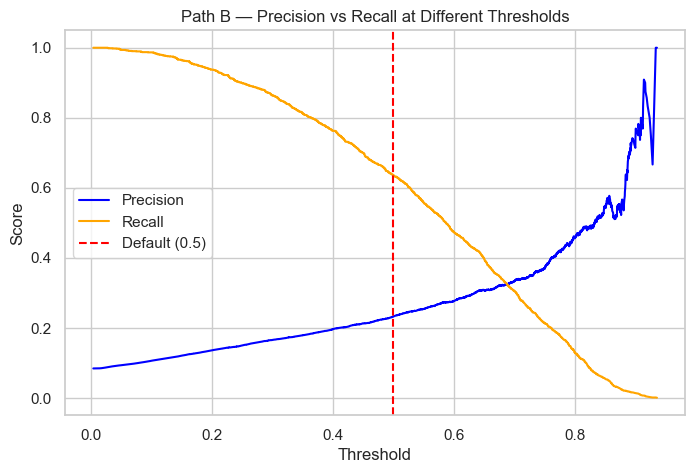

Best threshold: 0.58
Best F1:        0.3555


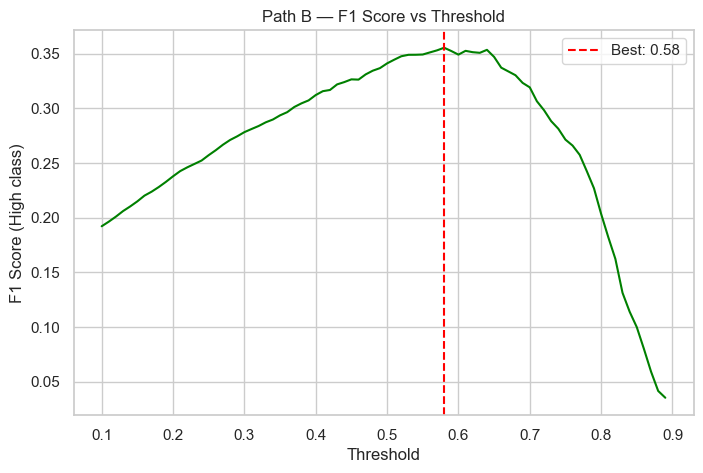

In [42]:
# Precision-Recall curve
precisions_b, recalls_b, thresholds_b = precision_recall_curve(y_test, y_prob_b_tuned)

plt.figure(figsize=(8, 5))
plt.plot(thresholds_b, precisions_b[:-1], label="Precision", color="blue")
plt.plot(thresholds_b, recalls_b[:-1], label="Recall", color="orange")
plt.axvline(x=0.5, color="red", linestyle="--", label="Default (0.5)")
plt.xlabel("Threshold")
plt.ylabel("Score")
plt.title("Path B — Precision vs Recall at Different Thresholds")
plt.legend()
plt.grid(True)
plt.show()

# F1 vs Threshold
thresholds_range = np.arange(0.1, 0.9, 0.01)
f1_scores_b = [
    f1_score(y_test, (y_prob_b_tuned >= t).astype(int)) for t in thresholds_range
]
best_thresh_b = thresholds_range[np.argmax(f1_scores_b)]
best_f1_b = max(f1_scores_b)

print(f"Best threshold: {best_thresh_b:.2f}")
print(f"Best F1:        {best_f1_b:.4f}")

plt.figure(figsize=(8, 5))
plt.plot(thresholds_range, f1_scores_b, color="green")
plt.axvline(
    x=best_thresh_b, color="red", linestyle="--", label=f"Best: {best_thresh_b:.2f}"
)
plt.xlabel("Threshold")
plt.ylabel("F1 Score (High class)")
plt.title("Path B — F1 Score vs Threshold")
plt.legend()
plt.grid(True)
plt.show()

In [43]:
y_pred_b_best = (y_prob_b_tuned >= best_thresh_b).astype(int)

print(f"=== Path B XGBoost @ threshold {best_thresh_b:.2f} ===")
print(classification_report(y_test, y_pred_b_best, target_names=["Low", "High"]))
print("AUC-ROC:", round(roc_auc_score(y_test, y_prob_b_tuned), 4))
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_b_best))

=== Path B XGBoost @ threshold 0.58 ===
              precision    recall  f1-score   support

         Low       0.95      0.87      0.91     15595
        High       0.27      0.51      0.36      1437

    accuracy                           0.84     17032
   macro avg       0.61      0.69      0.63     17032
weighted avg       0.89      0.84      0.86     17032

AUC-ROC: 0.8125
Confusion Matrix:
[[13614  1981]
 [  698   739]]


In [44]:
# Log the threshold-optimised result as its own MLflow run
with mlflow.start_run(run_name="XGBoost_Tuned_BestThresh_PathB"):
    mlflow.set_tags(
        {
            "path": "B",
            "representation": "base-emb",
            "model_type": "XGBoost",
            "variant": "best_threshold",
        }
    )
    mlflow.log_params(
        {
            "n_estimators": 500,
            "max_depth": 6,
            "learning_rate": 0.05,
            "scale_pos_weight": scale,
            "eval_metric": "auc",
            "early_stopping_rounds": 20,
        }
    )
    log_run_metrics(y_test, y_pred_b_best, y_prob_b_tuned, threshold=best_thresh_b)
    # Model artifact already logged under XGBoost_Tuned_PathB — no need to re-log
    print(f"Threshold-optimised run logged (thresh={best_thresh_b:.2f})")


Threshold-optimised run logged (thresh=0.58)


### PATH B — Dynamic Results

In [45]:
results_b = []

# Collect from multi-model loop — rebuild predictions for each stored model
for name, model in models_b.items():
    y_pred_ = model.predict(X_test_b)
    y_proba_ = model.predict_proba(X_test_b)[:, 1]
    results_b.append(get_metrics(y_test, y_pred_, y_proba_, name))

# Tuned XGBoost at default threshold
results_b.append(get_metrics(y_test, y_pred_b_tuned, y_prob_b_tuned, "XGBoost Tuned"))

# Tuned XGBoost at best F1 threshold
results_b.append(
    get_metrics(
        y_test,
        (y_prob_b_tuned >= best_thresh_b).astype(int),
        y_prob_b_tuned,
        f"XGBoost Tuned (thresh={best_thresh_b:.2f})",
        threshold=best_thresh_b,
    )
)

df_results_b = pd.DataFrame(results_b).sort_values("F1 (Hi)", ascending=False)
best_b_idx = df_results_b["F1 (Hi)"].idxmax()

print("=" * 65)
print("PATH B — Results Summary")
print("=" * 65)
print(df_results_b.to_string(index=False))
print(f"\n✓  Best model (by F1): {df_results_b.loc[best_b_idx, 'Model']}")


PATH B — Results Summary
                      Model  Threshold  Precision (Hi)  Recall (Hi)  F1 (Hi)  AUC-ROC  Accuracy
XGBoost Tuned (thresh=0.58)       0.58           0.272        0.514    0.356   0.8125    0.8427
              XGBoost Tuned       0.50           0.233        0.637    0.341   0.8125    0.7926
                    XGBoost       0.50           0.253        0.522    0.340   0.8045    0.8293
        Logistic Regression       0.50           0.179        0.733    0.287   0.7812    0.6933
              Random Forest       0.50           0.714        0.007    0.014   0.7630    0.9160

✓  Best model (by F1): XGBoost Tuned (thresh=0.58)


---
# PATH C — Fine-Tuned Embeddings

### Load / Compute Fine-Tuned Embeddings

In [46]:
emb_model_ft = SentenceTransformer("../artifacts/finetuned_embedding_model")

if os.path.exists("../data/processed/text_embeddings_ft.npy"):
    print("Loading cached fine-tuned embeddings...")
    text_embeddings_c = np.load("../data/processed/text_embeddings_ft.npy")
else:
    print("Computing fine-tuned embeddings...")
    text_embeddings_c = emb_model_ft.encode(
        X_text.tolist(), batch_size=256, show_progress_bar=True, device="cuda"
    )
    np.save("../data/processed/text_embeddings_ft.npy", text_embeddings_c)

print("Fine-tuned embeddings shape:", text_embeddings_c.shape)

Loading weights: 100%|██████████| 103/103 [00:00<00:00, 2787.43it/s]


Loading cached fine-tuned embeddings...
Fine-tuned embeddings shape: (85156, 384)


### Align Train/Test Splits

In [47]:
X_text_train_emb_c = text_embeddings_c[X_text_train.index]
X_text_test_emb_c = text_embeddings_c[X_text_test.index]

X_text_train_emb_c_csr = csr_matrix(X_text_train_emb_c)
X_text_test_emb_c_csr = csr_matrix(X_text_test_emb_c)

print("Train embeddings (ft):", X_text_train_emb_c_csr.shape)
print("Test  embeddings (ft):", X_text_test_emb_c_csr.shape)

Train embeddings (ft): (68124, 384)
Test  embeddings (ft): (17032, 384)


### Combine Features

In [48]:
X_train_c = hstack([X_text_train_emb_c_csr, X_meta_train_encoded, X_add_train_scaled])
X_test_c = hstack([X_text_test_emb_c_csr, X_meta_test_encoded, X_add_test_scaled])

print("X_train_c:", X_train_c.shape)
print("X_test_c: ", X_test_c.shape)

X_train_c: (68124, 455)
X_test_c:  (17032, 455)


### Multi-Model Comparison

In [49]:
models_c = {
    "Logistic Regression": LogisticRegression(
        C=1, class_weight="balanced", max_iter=1000, random_state=42, n_jobs=-1
    ),
    "Random Forest": RandomForestClassifier(
        n_estimators=100, random_state=42, n_jobs=-1, class_weight="balanced"
    ),
    "XGBoost": XGBClassifier(
        n_estimators=200,
        max_depth=6,
        learning_rate=0.1,
        scale_pos_weight=scale,
        tree_method="hist",
        eval_metric="auc",
        device="cuda",
        random_state=42,
        n_jobs=-1,
    ),
}

_c_params = {
    "Logistic Regression": {"C": 1, "class_weight": "balanced", "max_iter": 1000},
    "Random Forest": {"n_estimators": 100, "class_weight": "balanced"},
    "XGBoost": {"n_estimators": 200, "max_depth": 6, "learning_rate": 0.1},
}

for name, model in models_c.items():
    run_name = name.replace(" ", "_") + "_PathC"
    with mlflow.start_run(run_name=run_name):
        mlflow.set_tags(
            {"path": "C", "representation": "finetuned-emb", "model_type": name}
        )
        mlflow.log_params(_c_params[name])

        print(f"\n{'=' * 50}")
        print(f"Training: {name}")
        if name == "XGBoost":
            model.fit(X_train_c, y_train, eval_set=[(X_test_c, y_test)], verbose=50)
        else:
            model.fit(X_train_c, y_train)
        y_pred = model.predict(X_test_c)
        y_proba = model.predict_proba(X_test_c)[:, 1]

        log_run_metrics(y_test, y_pred, y_proba)
        mlflow.sklearn.log_model(model, "model")

        print(classification_report(y_test, y_pred, target_names=["Low", "High"]))
        print("AUC-ROC:", round(roc_auc_score(y_test, y_proba), 4))



Training: Logistic Regression


d:\Projects\Machine Learning\bug-priority-classifier\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1184: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)
2026/03/15 22:51:20 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/03/15 22:51:20 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


              precision    recall  f1-score   support

         Low       0.97      0.68      0.80     15595
        High       0.18      0.75      0.29      1437

    accuracy                           0.69     17032
   macro avg       0.57      0.72      0.54     17032
weighted avg       0.90      0.69      0.76     17032

AUC-ROC: 0.7819

Training: Random Forest


2026/03/15 22:53:20 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/03/15 22:53:20 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


              precision    recall  f1-score   support

         Low       0.92      1.00      0.96     15595
        High       0.71      0.00      0.01      1437

    accuracy                           0.92     17032
   macro avg       0.82      0.50      0.48     17032
weighted avg       0.90      0.92      0.88     17032

AUC-ROC: 0.7528

Training: XGBoost
[0]	validation_0-auc:0.77822
[50]	validation_0-auc:0.80738
[100]	validation_0-auc:0.80690
[150]	validation_0-auc:0.80335
[199]	validation_0-auc:0.79967


2026/03/15 22:53:34 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/03/15 22:53:34 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


              precision    recall  f1-score   support

         Low       0.95      0.86      0.90     15595
        High       0.25      0.51      0.34      1437

    accuracy                           0.83     17032
   macro avg       0.60      0.69      0.62     17032
weighted avg       0.89      0.83      0.86     17032

AUC-ROC: 0.7997


### XGBoost Tuned (Early Stopping)

In [50]:
with mlflow.start_run(run_name="XGBoost_Tuned_PathC"):
    mlflow.set_tags(
        {
            "path": "C",
            "representation": "finetuned-emb",
            "model_type": "XGBoost",
            "variant": "early_stop",
        }
    )
    mlflow.log_params(
        {
            "n_estimators": 500,
            "max_depth": 6,
            "learning_rate": 0.05,
            "scale_pos_weight": scale,
            "eval_metric": "auc",
            "early_stopping_rounds": 20,
        }
    )

    xgb_c_tuned = XGBClassifier(
        n_estimators=500,
        max_depth=6,
        learning_rate=0.05,
        scale_pos_weight=scale,
        tree_method="hist",
        eval_metric="auc",
        early_stopping_rounds=20,
        device="cuda",
        random_state=42,
        n_jobs=-1,
    )
    xgb_c_tuned.fit(X_train_c, y_train, eval_set=[(X_test_c, y_test)], verbose=50)

    y_pred_c_tuned = xgb_c_tuned.predict(X_test_c)
    y_prob_c_tuned = xgb_c_tuned.predict_proba(X_test_c)[:, 1]

    mlflow.log_metric("best_iteration", xgb_c_tuned.best_iteration)
    log_run_metrics(y_test, y_pred_c_tuned, y_prob_c_tuned)
    mlflow.xgboost.log_model(xgb_c_tuned, "model")

    print("\nTuned XGBoost (Path C):")
    print(classification_report(y_test, y_pred_c_tuned, target_names=["Low", "High"]))
    print("AUC-ROC:", round(roc_auc_score(y_test, y_prob_c_tuned), 4))
    print("Best iteration:", xgb_c_tuned.best_iteration)


[0]	validation_0-auc:0.77822
[50]	validation_0-auc:0.80381
[100]	validation_0-auc:0.81015
[129]	validation_0-auc:0.81037


2026/03/15 22:53:45 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.



Tuned XGBoost (Path C):
              precision    recall  f1-score   support

         Low       0.96      0.76      0.85     15595
        High       0.21      0.70      0.33      1437

    accuracy                           0.76     17032
   macro avg       0.59      0.73      0.59     17032
weighted avg       0.90      0.76      0.81     17032

AUC-ROC: 0.8108
Best iteration: 109


### Threshold Analysis

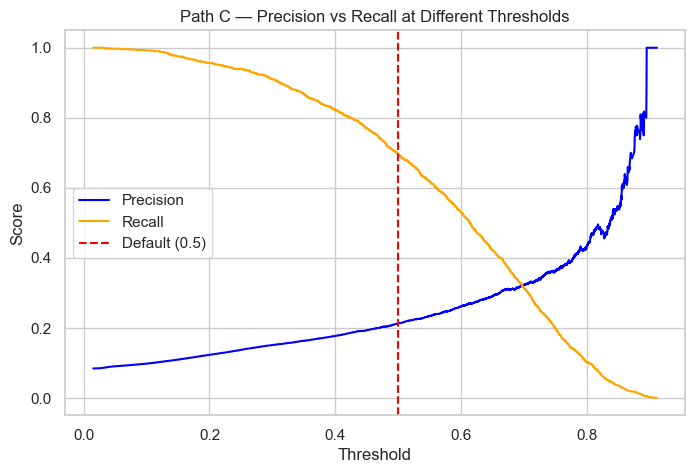

Best threshold: 0.61
Best F1:        0.3513


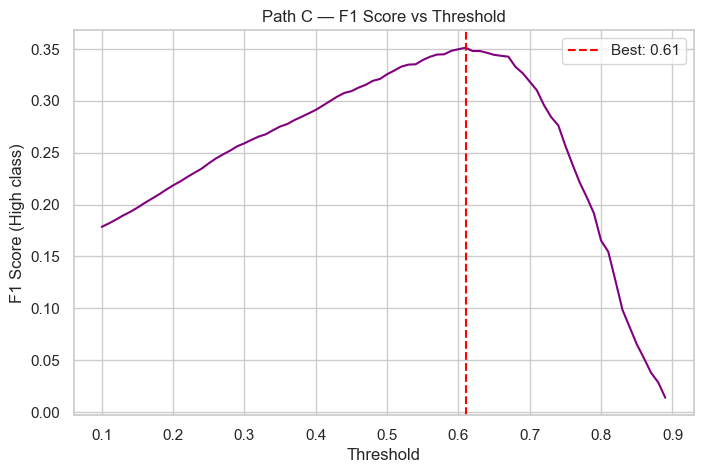

In [51]:
# Precision-Recall curve
precisions_c, recalls_c, thresholds_c = precision_recall_curve(y_test, y_prob_c_tuned)

plt.figure(figsize=(8, 5))
plt.plot(thresholds_c, precisions_c[:-1], label="Precision", color="blue")
plt.plot(thresholds_c, recalls_c[:-1], label="Recall", color="orange")
plt.axvline(x=0.5, color="red", linestyle="--", label="Default (0.5)")
plt.xlabel("Threshold")
plt.ylabel("Score")
plt.title("Path C — Precision vs Recall at Different Thresholds")
plt.legend()
plt.grid(True)
plt.show()

# F1 vs Threshold
thresholds_range = np.arange(0.1, 0.9, 0.01)  # redefined: Path C is self-contained
f1_scores_c = [
    f1_score(y_test, (y_prob_c_tuned >= t).astype(int)) for t in thresholds_range
]
best_thresh_c = thresholds_range[np.argmax(f1_scores_c)]
best_f1_c = max(f1_scores_c)

print(f"Best threshold: {best_thresh_c:.2f}")
print(f"Best F1:        {best_f1_c:.4f}")

plt.figure(figsize=(8, 5))
plt.plot(thresholds_range, f1_scores_c, color="purple")
plt.axvline(
    x=best_thresh_c, color="red", linestyle="--", label=f"Best: {best_thresh_c:.2f}"
)
plt.xlabel("Threshold")
plt.ylabel("F1 Score (High class)")
plt.title("Path C — F1 Score vs Threshold")
plt.legend()
plt.grid(True)
plt.show()

In [52]:
y_pred_c_best = (y_prob_c_tuned >= best_thresh_c).astype(int)

print(f"=== Path C XGBoost @ threshold {best_thresh_c:.2f} ===")
print(classification_report(y_test, y_pred_c_best, target_names=["Low", "High"]))
print("AUC-ROC:", round(roc_auc_score(y_test, y_prob_c_tuned), 4))
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_c_best))

=== Path C XGBoost @ threshold 0.61 ===
              precision    recall  f1-score   support

         Low       0.95      0.87      0.91     15595
        High       0.27      0.51      0.35      1437

    accuracy                           0.84     17032
   macro avg       0.61      0.69      0.63     17032
weighted avg       0.89      0.84      0.86     17032

AUC-ROC: 0.8108
Confusion Matrix:
[[13582  2013]
 [  702   735]]


In [53]:
# Log the threshold-optimised result as its own MLflow run
with mlflow.start_run(run_name="XGBoost_Tuned_BestThresh_PathC"):
    mlflow.set_tags(
        {
            "path": "C",
            "representation": "finetuned-emb",
            "model_type": "XGBoost",
            "variant": "best_threshold",
        }
    )
    mlflow.log_params(
        {
            "n_estimators": 500,
            "max_depth": 6,
            "learning_rate": 0.05,
            "scale_pos_weight": scale,
            "eval_metric": "auc",
            "early_stopping_rounds": 20,
        }
    )
    log_run_metrics(y_test, y_pred_c_best, y_prob_c_tuned, threshold=best_thresh_c)
    print(f"Threshold-optimised run logged (thresh={best_thresh_c:.2f})")


Threshold-optimised run logged (thresh=0.61)


### PATH C — Dynamic Results

In [54]:
results_c = []

for name, model in models_c.items():
    y_pred_ = model.predict(X_test_c)
    y_proba_ = model.predict_proba(X_test_c)[:, 1]
    results_c.append(get_metrics(y_test, y_pred_, y_proba_, name))

results_c.append(get_metrics(y_test, y_pred_c_tuned, y_prob_c_tuned, "XGBoost Tuned"))

results_c.append(
    get_metrics(
        y_test,
        (y_prob_c_tuned >= best_thresh_c).astype(int),
        y_prob_c_tuned,
        f"XGBoost Tuned (thresh={best_thresh_c:.2f})",
        threshold=best_thresh_c,
    )
)

df_results_c = pd.DataFrame(results_c).sort_values("F1 (Hi)", ascending=False)
best_c_idx = df_results_c["F1 (Hi)"].idxmax()

print("=" * 65)
print("PATH C — Results Summary")
print("=" * 65)
print(df_results_c.to_string(index=False))
print(f"\n✓  Best model (by F1): {df_results_c.loc[best_c_idx, 'Model']}")


PATH C — Results Summary
                      Model  Threshold  Precision (Hi)  Recall (Hi)  F1 (Hi)  AUC-ROC  Accuracy
XGBoost Tuned (thresh=0.61)       0.61           0.267        0.511    0.351   0.8108    0.8406
                    XGBoost       0.50           0.255        0.509    0.339   0.7997    0.8330
              XGBoost Tuned       0.50           0.213        0.696    0.326   0.8108    0.7569
        Logistic Regression       0.50           0.179        0.749    0.289   0.7819    0.6889
              Random Forest       0.50           0.714        0.003    0.007   0.7528    0.9158

✓  Best model (by F1): XGBoost Tuned (thresh=0.61)


---
# Final Results — Path A vs B vs C

In [55]:
# ── 3-Way Path Comparison: pick best model per path ──────────────────────────

best_a = df_results_a.loc[df_results_a["F1 (Hi)"].idxmax()].copy()
best_b = df_results_b.loc[df_results_b["F1 (Hi)"].idxmax()].copy()
best_c = df_results_c.loc[df_results_c["F1 (Hi)"].idxmax()].copy()

best_a["Path"] = "A — TF-IDF"
best_b["Path"] = "B — Base Embeddings"
best_c["Path"] = "C — Fine-tuned Embeddings"

df_final = pd.DataFrame([best_a, best_b, best_c]).set_index("Path")[
    [
        "Model",
        "Threshold",
        "Precision (Hi)",
        "Recall (Hi)",
        "F1 (Hi)",
        "AUC-ROC",
        "Accuracy",
    ]
]

print("=" * 75)
print("FINAL COMPARISON — Best Model Per Path")
print("=" * 75)
print(df_final.to_string())

# ── Delta vs Path A ───────────────────────────────────────────────────────────
print("\n── Delta vs Path A ──")
for metric in ["F1 (Hi)", "AUC-ROC", "Precision (Hi)", "Recall (Hi)"]:
    base = float(best_a[metric])
    for path, row in [("B", best_b), ("C", best_c)]:
        delta = float(row[metric]) - base
        sign = "+" if delta >= 0 else ""
        print(f"  {metric:<18} Path {path} vs A: {sign}{delta:.4f}")

# ── Verdict ───────────────────────────────────────────────────────────────────
winner_path = df_final["F1 (Hi)"].idxmax()
winner_row = df_final.loc[winner_path]
print(f"\n{'=' * 75}")
print(f"WINNER: {winner_path}")
print(f"  Model:         {winner_row['Model']}")
print(f"  F1 (Hi):       {winner_row['F1 (Hi)']}")
print(f"  AUC-ROC:       {winner_row['AUC-ROC']}")
print(f"  Threshold:     {winner_row['Threshold']}")

b_auc = float(best_b["AUC-ROC"])
c_auc = float(best_c["AUC-ROC"])
verdict = (
    "Fine-tuned embeddings (Path C) improve AUC-ROC by >{:.4f} over base — use Path C model.".format(
        c_auc - b_auc
    )
    if (c_auc - b_auc) > 0.01
    else "Fine-tuned embeddings do NOT improve AUC-ROC by >0.01 — Path B base embeddings are sufficient."
)
print(f"\nEmbedding verdict: {verdict}")


FINAL COMPARISON — Best Model Per Path
                                                 Model  Threshold  Precision (Hi)  Recall (Hi)  F1 (Hi)  AUC-ROC  Accuracy
Path                                                                                                                      
A — TF-IDF                               LR (balanced)       0.50           0.189        0.677    0.295   0.7740    0.7275
B — Base Embeddings        XGBoost Tuned (thresh=0.58)       0.58           0.272        0.514    0.356   0.8125    0.8427
C — Fine-tuned Embeddings  XGBoost Tuned (thresh=0.61)       0.61           0.267        0.511    0.351   0.8108    0.8406

── Delta vs Path A ──
  F1 (Hi)            Path B vs A: +0.0610
  F1 (Hi)            Path C vs A: +0.0560
  AUC-ROC            Path B vs A: +0.0385
  AUC-ROC            Path C vs A: +0.0368
  Precision (Hi)     Path B vs A: +0.0830
  Precision (Hi)     Path C vs A: +0.0780
  Recall (Hi)        Path B vs A: -0.1630
  Recall (Hi)        Path C v

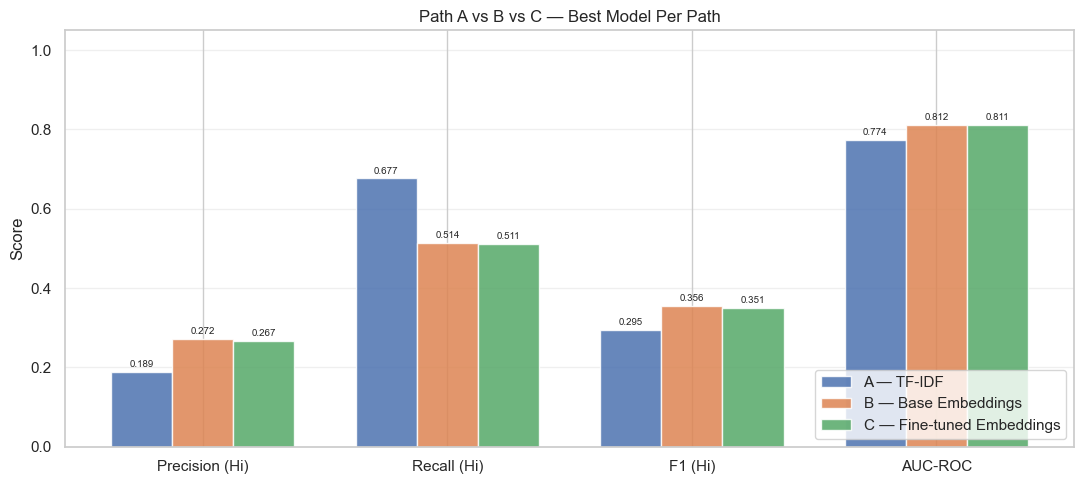

In [56]:
metrics_to_plot = ["Precision (Hi)", "Recall (Hi)", "F1 (Hi)", "AUC-ROC"]
paths = ["A — TF-IDF", "B — Base Embeddings", "C — Fine-tuned Embeddings"]
colors = ["#4C72B0", "#DD8452", "#55A868"]

x = np.arange(len(metrics_to_plot))
width = 0.25

fig, ax = plt.subplots(figsize=(11, 5))
for j, (path, color) in enumerate(zip(paths, colors)):
    vals = [float(df_final.loc[path, m]) for m in metrics_to_plot]
    bars = ax.bar(x + j * width, vals, width, label=path, color=color, alpha=0.85)
    ax.bar_label(bars, fmt="%.3f", padding=2, fontsize=7)

ax.set_xticks(x + width)
ax.set_xticklabels(metrics_to_plot)
ax.set_ylim(0, 1.05)
ax.set_ylabel("Score")
ax.set_title("Path A vs B vs C — Best Model Per Path")
ax.legend(loc="lower right")
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()


## Save Artifacts

In [ ]:
os.makedirs("../artifacts", exist_ok=True)

# Save best model (update path variable based on final results)
best_model = xgb_b_tuned  # replace with xgb_c_tuned if Path C wins
best_path_tag = "path_b"  # replace with "path_c" if applicable

joblib.dump(best_model, f"../artifacts/final_xgboost_{best_path_tag}.pkl")
joblib.dump(tfidf, "../artifacts/tfidf.pkl")  # needed for Path A inference
joblib.dump(ohe, "../artifacts/ohe.pkl")
joblib.dump(scaler, "../artifacts/scaler.pkl")

config = {
    "path": best_path_tag,
    "threshold": 0.50,
    "embedding_model": "all-MiniLM-L6-v2",  # update if path_c
    "embedding_dims": 384,
    "feature_dims": X_train_b.shape[1],
    "best_iteration": getattr(best_model, "best_iteration", None),
}

with open("../artifacts/config.json", "w") as f:
    json.dump(config, f, indent=2)

print("Artifacts saved.")
print(json.dumps(config, indent=2))

Artifacts saved.
{
  "path": "path_b",
  "threshold": 0.5,
  "embedding_model": "all-MiniLM-L6-v2",
  "embedding_dims": 384,
  "feature_dims": 455,
  "best_iteration": 209
}


## Debug / Verification

In [58]:
# Verify feature matrix alignment
print("X_train_b breakdown:")
print("  Embedding  :", X_text_train_emb_b_csr.shape)
print("  OHE        :", X_meta_train_encoded.shape)
print("  Additional :", X_add_train_scaled.shape)
print("  Total      :", X_train_b.shape)

# Sanity check on prediction distribution
for tag, prob in [("B", y_prob_b_tuned), ("C", y_prob_c_tuned)]:
    print(f"\nPath {tag} prob distribution:")
    print(f"  Min:  {prob.min():.4f}")
    print(f"  Max:  {prob.max():.4f}")
    print(f"  Mean: {prob.mean():.4f}")

X_train_b breakdown:
  Embedding  : (68124, 384)
  OHE        : (68124, 64)
  Additional : (68124, 7)
  Total      : (68124, 455)

Path B prob distribution:
  Min:  0.0034
  Max:  0.9361
  Mean: 0.3099

Path C prob distribution:
  Min:  0.0153
  Max:  0.9118
  Mean: 0.3452


In [59]:
# Components and versions available (for inference)
print("Components:", sorted(df_clean["component"].unique()))
print("Versions:  ", sorted(df_clean["version"].unique()))
print("Total components:", df_clean["component"].nunique())
print("Total versions:  ", df_clean["version"].nunique())

Components: ['Ant', 'CVS', 'Compare', 'Debug', 'Doc', 'IDE', 'Incubator', 'PMC', 'Releng', 'Resources', 'Runtime', 'SWT', 'Scripting', 'Search', 'Team', 'Text', 'UI', 'Update  (deprecated - use RT>Equinox>p2)', 'User Assistance', 'WebDAV', 'Website']
Versions:   ['1.0', '2.0', '2.0.1', '2.0.2', '2.1', '2.1.1', '2.1.2', '2.1.3', '3.0', '3.0.1', '3.0.2', '3.1', '3.1.1', '3.1.2', '3.2', '3.2.1', '3.2.2', '3.3', '3.3.1', '3.3.2', '3.4', '3.4.1', '3.4.2', '3.5', '3.5.1', '3.5.2', '3.6', '3.6.1', '3.6.2', '3.7', '3.7.1', '3.7.2', '3.8', '3.8.1', '3.8.2', '4.0', '4.1', '4.2', '4.2.1', '4.2.2', '4.3', '4.3.1', '4.4']
Total components: 21
Total versions:   43


In [60]:
# Sample high-priority bug for inference testing
sample = df_clean[df_clean["target"] == 1].iloc[0]
print("Component:", sample["component"])
print("Version:  ", sample["version"])
print("Text:     ", sample["text"][:200])

Component: Team
Version:   2.0
Text:      workspace files thought it would be useful if the set of repo connections could be stored somewhere external in the file system instead of everyone having their own list cashed in their workspace meta


In [61]:
print(mlflow.get_tracking_uri())


sqlite:///D:/Projects/Machine Learning/bug-priority-classifier/mlflow.db
